In [1]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy import stats

az.style.use('arviz-darkgrid')

plt.style.use('ggplot')


g++ not available, if using conda: `conda install gxx`


# Bayesian Hypothesis Testing

In the previous notebooks we learned how to turn a prior and a likelihood into a posterior. In this one, we will use these posterior probabilities for hypothesis testing.

In the frequentist view, we use p-values to test our hypothesis. This could be too rigid in some circumstances. For example $p = 0.045$ and $p = 0.00001$ both reject $H_0$ and treating these two similarly sounds absurd from the beginning. Not only us, but the well known statistician Ronald Fisher also criticized this logic. He argued that using p-values mechanistically does not make any sense.

In the Bayesian world there is no p-value or mechanical decision to claim "reject $H_0$" or "fail to reject $H_0$". Instead we look directly at the posterior of the quantity we care about and read the answer off it.

We will start with hypothesis testing using credible and highest density intervals that we defined in the "Introduction to Bayesian Statistics" notebook. Then we will continue with the Region of Practical Equivalence and lastly we will define Bayes Factors. Once we connect all the dots, we will work on a couple of hypothesis testing examples.



## Making Decisions from the Posterior Distribution

In a t-test, what we are doing is basically looking at the place of 0 with respect to difference in means and making inferences based on the pooled standard error of this difference distribution. If 0 is far enough from the difference in standard error units at the desired critical level, we reject $H_0$. Similarly, in Bayesian statistics we look at the highest density interval (HDI). For example, if we have a mean difference posterior distribution:

$\text{mean posterior difference} \sim \mathcal{N}(2,0.7^2)$



In [2]:
np.random.seed(42)
mean_posterior_difference = np.random.normal(2,0.7, size = 1000)
credible_interval = np.percentile(mean_posterior_difference, [2.5, 97.5])
mean_posterior_difference_hdi = az.hdi(mean_posterior_difference, prob=0.95)

print(f"95% credible interval for the difference: [{credible_interval[0]:.2f}, {credible_interval[1]:.2f}] cm")
print(f"95% HDI for the difference: [{mean_posterior_difference_hdi[0]:.2f}, {mean_posterior_difference_hdi[1]:.2f}] cm")


95% credible interval for the difference: [0.71, 3.34] cm
95% HDI for the difference: [0.69, 3.33] cm


Notice that the results are pretty similar. In symmetric distributions, the narrowest interval covering 95% of the total probability is the same as the 95% equal tailed credible interval.



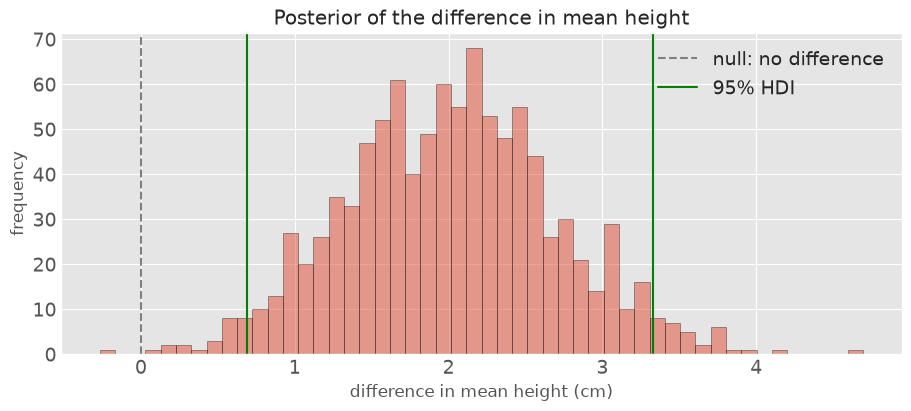

In [3]:
plt.figure(figsize=(9, 4))
plt.hist(mean_posterior_difference, bins=50, edgecolor = 'black', alpha = 0.5)
plt.axvline(0, color="grey", linestyle="--", label="null: no difference")
plt.axvline(mean_posterior_difference_hdi[0], color="green", linestyle="-", label="95% HDI")
plt.axvline(mean_posterior_difference_hdi[1], color="green", linestyle="-")
plt.xlabel("difference in mean height (cm)")
plt.ylabel("frequency")
plt.title("Posterior of the difference in mean height")
plt.legend()
plt.show()


## The Region of Practical Equivalence

HDI and credible intervals tell us about the uncertainty in the difference; however, they do not say anything about its practical importance. In the frequentist world, we use effect size measures alongside the hypothesis tests we perform. In the Bayesian world, we can use the region of practical equivalence (ROPE).

For example, in this case let as assume that results between -0.5 and 0.5 shouldn't be considered significant. The difference is too small, so there is nothing to report. This region is called ROPE. Based on the place of the HDI with respect to the ROPE region, we conclude the significance of a difference.

$\text{ROPE} = [-0.5,0.5]$



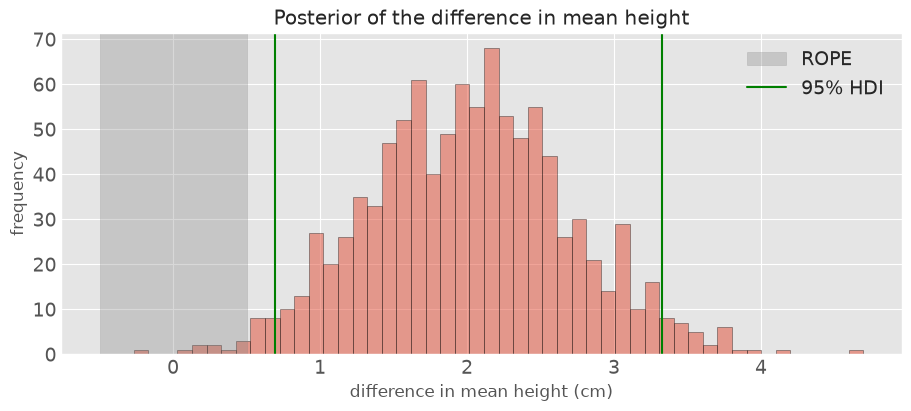

In [4]:
rope = (-0.5, 0.5)

plt.figure(figsize=(9, 4))
plt.hist(mean_posterior_difference, bins=50, edgecolor = 'black', alpha = 0.5)
plt.axvspan(rope[0], rope[1], color='grey', alpha=0.3, label="ROPE")
plt.axvline(mean_posterior_difference_hdi[0], color="green", linestyle="-", label="95% HDI")
plt.axvline(mean_posterior_difference_hdi[1], color="green", linestyle="-")
plt.xlabel("difference in mean height (cm)")
plt.ylabel("frequency")
plt.title("Posterior of the difference in mean height")
plt.legend()
plt.show()


Here the HDI lies entirely outside the ROPE. Then every credible value is practically meaningful, so we reject $H_0$ and conclude that the difference is significant.


What if the HDI is entirely inside the ROPE? Then every credible value is practically negligible, so we accept $H_0$ and conclude that the difference is not significant.

**Example**

$\text{mean posterior difference} \sim \mathcal{N}(0,0.15^2)$

$\text{ROPE} = [-0.5,0.5]$


In [5]:
np.random.seed(42)
negligible_mean_difference = np.random.normal(0,0.15, size = 1000)
negligible_mean_difference_hdi = az.hdi(negligible_mean_difference, prob=0.95)

print(f"95% HDI for the difference: [{negligible_mean_difference_hdi[0]:.2f}, {negligible_mean_difference_hdi[1]:.2f}] cm")


95% HDI for the difference: [-0.28, 0.28] cm


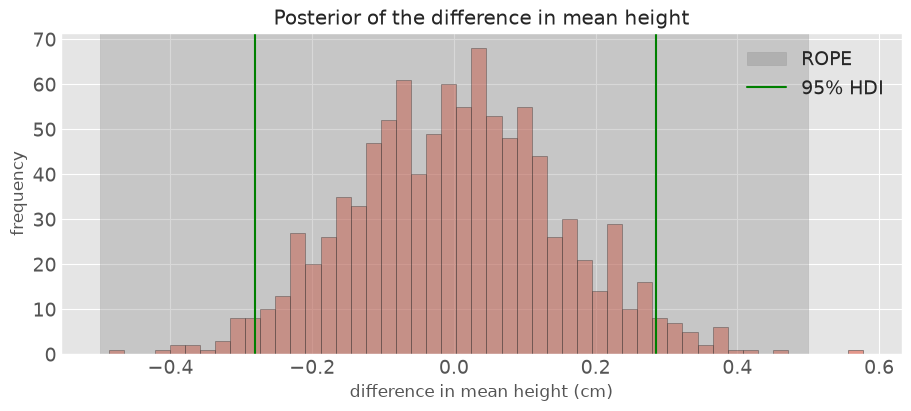

In [6]:
rope = (-0.5, 0.5)

plt.figure(figsize=(9, 4))
plt.hist(negligible_mean_difference, bins=50, edgecolor = 'black', alpha = 0.5)
plt.axvspan(rope[0], rope[1], color='grey', alpha=0.3, label="ROPE")
plt.axvline(negligible_mean_difference_hdi[0], color="green", linestyle="-", label="95% HDI")
plt.axvline(negligible_mean_difference_hdi[1], color="green", linestyle="-")
plt.xlabel("difference in mean height (cm)")
plt.ylabel("frequency")
plt.title("Posterior of the difference in mean height")
plt.legend()
plt.show()


What if the HDI only partially overlaps the ROPE? Then we do not have enough evidence to reject $H_0$, and the result is inconclusive.

**Example**

$\text{mean posterior difference} \sim \mathcal{N}(1,0.7^2)$

$\text{ROPE} = [-0.5,0.5]$


In [7]:
np.random.seed(42)
moderate_mean_difference = np.random.normal(1,0.7, size = 1000)
moderate_mean_difference_hdi = az.hdi(moderate_mean_difference, prob=0.95)

print(f"95% HDI for the difference: [{moderate_mean_difference_hdi[0]:.2f}, {moderate_mean_difference_hdi[1]:.2f}] cm")


95% HDI for the difference: [-0.31, 2.33] cm


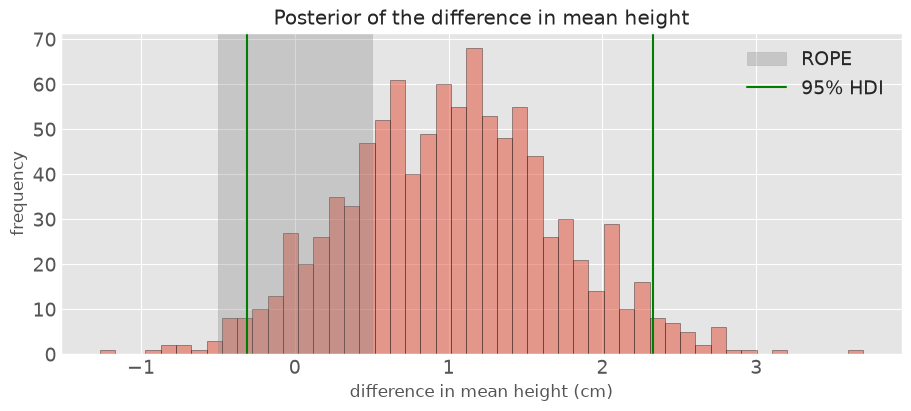

In [8]:
rope = (-0.5, 0.5)

plt.figure(figsize=(9, 4))
plt.hist(moderate_mean_difference, bins=50, edgecolor = 'black', alpha = 0.5)
plt.axvspan(rope[0], rope[1], color='grey', alpha=0.3, label="ROPE")
plt.axvline(moderate_mean_difference_hdi[0], color="green", linestyle="-", label="95% HDI")
plt.axvline(moderate_mean_difference_hdi[1], color="green", linestyle="-")
plt.xlabel("difference in mean height (cm)")
plt.ylabel("frequency")
plt.title("Posterior of the difference in mean height")
plt.legend()
plt.show()


## Bayes Factor

Bayes factor is another tool in our toolbox for hypothesis testing. Unlike HDI and ROPE, Bayes factor directly compares the marginal likelihood of the data under $H_0$ and $H_1$:

$BF_{10} = \frac{p(\text{data} \mid H_1)}{p(\text{data} \mid H_0)}$

Calculation of these marginal likelihoods is hard. Luckily there is an alternative way, called "Savage-Dickey Density Ratio", allowing us to compute Bayes factor more efficiently. Under sample mean difference $\Delta$:

$H_0: \Delta = 0$

$H_1: \Delta \neq 0$

Savage-Dickey Density Ratio is 

$BF_{01} = \frac{p(\Delta = 0 \mid \text{data})}{p(\Delta = 0)}$

We are basically comparing the probability density at 0 in the delta posterior and the delta prior.

This shortcut does not work for every pair of hypotheses. First, it requires the priors on the remaining parameters, $\mu$ and $\sigma$, to be the same under both hypotheses. Secondly, it requires $H_0$ to be nested in $H_1$. For example, when we assign prior as

$\delta \sim C(0,r^2)$

the parameter space of $H_1$ already contains the point $\delta = 0$, so fixing $\delta$ there gives us $H_0$.

Once we have a Bayes factor we still need to read it. Jeffreys proposed the following scale for $BF_{10}$:

| $BF_{10}$ | Evidence for $H_1$ |
| --- | --- |
| 1 to 3 | not worth more than a bare mention |
| 3 to 10 | substantial |
| 10 to 30 | strong |
| 30 to 100 | very strong |
| above 100 | decisive |

Values below 1 should be read in reverse. As the Bayes factor gets smaller, the evidence that $H_1$ is not more likely compared to $H_0$ increases.

**Example**

$\Delta_{prior} \sim \mathcal{N}(0,1^2)$

$\Delta_{posterior} \sim \mathcal{N}(2,0.5^2)$



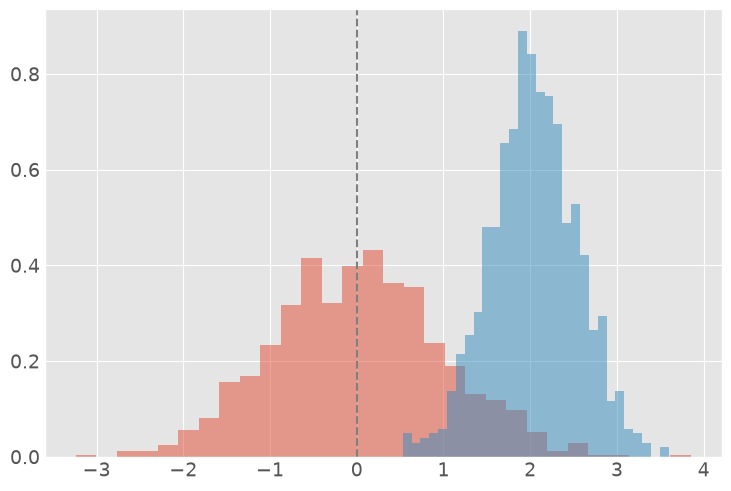

In [9]:
np.random.seed(42)

delta_prior = np.random.normal(0,1,size = 1000)
delta_posterior = np.random.normal(2,0.5, size = 1000)

plt.figure()
plt.hist(delta_prior, bins=30, alpha=0.5, label='Prior', density=True)
plt.hist(delta_posterior, bins=30, alpha=0.5, label='Posterior', density=True)
plt.axvline(0, color="grey", linestyle="--")
plt.show()

In [10]:
zero_prior_density = stats.norm.pdf(
    0,
    loc = delta_prior.mean(),
    scale = delta_prior.std()
)
zero_posterior_density = stats.norm.pdf(
    0,
    loc = delta_posterior.mean(),
    scale = delta_posterior.std()
)

bf01 = zero_posterior_density / zero_prior_density
bf10 = 1 / bf01

print("Bayes Factor (BF10):", bf10)


Bayes Factor (BF10): 2125.2596988192736


A large Bayes factor indicates that $H_1$ is more likely compared to $H_0$. This shouldn't be a surprise since we can verify it from the histogram plots above.


## Hypothesis Testing with MCMC

So far we assumed that we already have prior and posterior differences. Also we generated them by sampling from a Gaussian distribution, which allowed us to fit a normal distribution to the samples. But often this is not the case in real life. To combine different distributions as well as sampling from these distributions we need to use Markov Chain Monte Carlo methods, which we have seen in the "Introduction to Bayesian Statistics" notebook.



### The JZS Prior

The Jeffreys-Zellner-Siow (JZS) prior is a commonly used prior distribution in Bayesian hypothesis testing. It uses a Cauchy distribution (t-distribution with one degree of freedom) for the mean and Jeffreys' prior on the variance. For the hypotheses:

$H_0: \mu = \mu_0$

$H_1: \mu \neq \mu_0$

the priors will be

$\mu \sim C(\mu_0, r^2 \sigma^2)$

$p(\sigma^2) \propto \frac{1}{\sigma^2}$

$p(\sigma) \propto \frac{1}{\sigma} ; \sigma > 0$

So the prior should be centered around the null value. This allows us to be objective in hypothesis testing. Also this is one of Jeffreys' recommendations for constructing hypothesis tests. Unless we have strong evidence for a particular direction, we should obey these recommendations.

The scale $r$ sets how large an effect we expect a priori and is usually fixed at 1. Smaller $r$ values are preferred in analyses where the expected difference is small.

The same prior can also be written in a standardized form. Instead of placing the Cauchy on the effect itself, we place it on the effect divided by $\sigma$:

$\delta = \frac{\Delta}{\sigma}$

$\delta \sim C(0, r^2)$

So $\Delta$ is the effect on the original measurement scale, expressed in the units of the data, while $\delta$ is the same effect expressed in units of $\sigma$. Both write the same model, but only the standardized version keeps the prior free of $\sigma$, which is why the scale $r$ can be chosen without knowing the measurement units. It also means that the Savage-Dickey ratio has to be computed on $\delta$, since that is the parameter carrying the Cauchy prior.



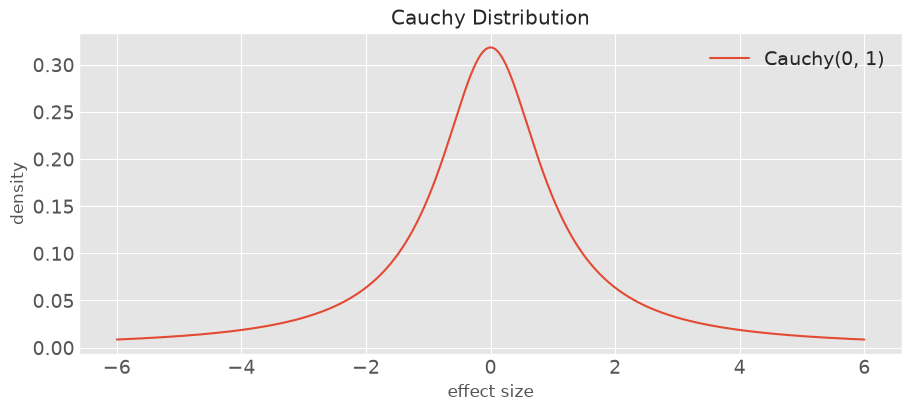

In [11]:
x = np.linspace(-6, 6, 1000)

plt.figure(figsize=(9, 4))
plt.plot(x, stats.cauchy.pdf(x, loc=0, scale=1), label="Cauchy(0, 1)")
plt.xlabel("effect size")
plt.ylabel("density")
plt.title("Cauchy Distribution")
plt.legend()
plt.show()


As seen above, the Cauchy distribution has fat tails, which allows the Bayesian model to use the data itself freely without restraining itself to its prior. `pymc` has no built in JZS prior, so we assemble it by hand, putting a Cauchy on the mean and adding the Jeffreys term on $\sigma$ through `pm.Potential`.


## Examples

In this section, the same examples will be used from "Clyde, M., Cetinkaya-Rundel, M., Rundel, C., Banks, D., Chai, C., & Huang, L. (2020). An Introduction to Bayesian Thinking: A Companion to the Statistics with R Course".

The data is directly fetched from the source itself.


**Example 1: Estimating a Single Mean (Page 90)**

Data:

$n = 28$

$\bar{y} = 55.52$

$s = 23.25$

Our hypotheses are:

$H_0: \mu = 35$

$H_1: \mu \neq 35$

Under the assumption of

$y \sim \mathcal{N}(\mu, \sigma^2)$

The corresponding JZS priors are:

$\mu \sim C(35, r^2 \sigma^2)$

$p(\sigma^2) \propto \frac{1}{\sigma^2}$

$p(\sigma) \propto \frac{1}{\sigma} ; \sigma > 0$

As suggested we will use $r = 1$.


In [12]:
single_mean_data = np.array([ 34.38,  39.33, 108.63,  88.  ,  81.  ,  49.25,  75.  ,  82.86,
        85.  ,  86.6 ,  70.  ,  81.  ,  17.46,  50.  ,  70.5 ,  58.38,
        35.3 ,  45.  ,  53.  ,  38.75,  38.  ,  31.69,  49.  ,  34.  ,
        44.  ,  50.  ,  23.54,  35.  ])

print("Sample Size:", single_mean_data.shape[0])
print("Mean:", single_mean_data.mean())
print("Standard Deviation:", single_mean_data.std(ddof=1))


Sample Size: 28
Mean: 55.52392857142858
Standard Deviation: 23.253986092278762


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, mu]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


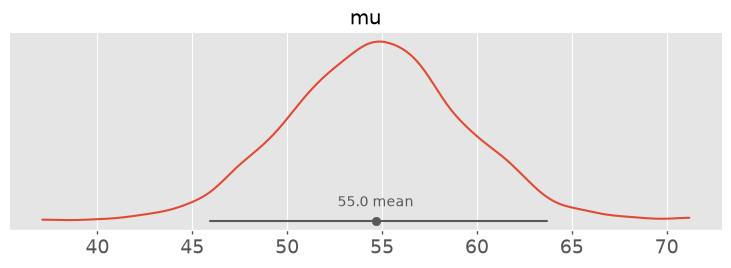

In [13]:
single_mean_prior_scale = 1

with pm.Model() as unstandardized_single_mean_model:

  sigma = pm.HalfFlat("sigma")
  pm.Potential("jeffrey", -pm.math.log(sigma))

  mu = pm.Cauchy("mu", alpha = 35, beta = sigma * single_mean_prior_scale)
  y = pm.Normal("y", mu = mu, sigma = sigma, observed = single_mean_data)

  unstandardized_single_mean_trace = pm.sample()

azp.plot_dist(unstandardized_single_mean_trace, var_names=["mu"], ci_kind="hdi", ci_prob=0.95)


In [14]:
az.summary(unstandardized_single_mean_trace, var_names=["mu", "sigma"], ci_kind="hdi", ci_prob=0.95)


,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,54.7,4.6,46,64,2682,2247,1.00,0.09,0.067
sigma,23.9,3.3,18,31,3587,2645,1.00,0.057,0.055


We can build a Bayesian model using these parameters. However, in this fashion we cannot compute the Bayes Factor through the Savage-Dickey Density Ratio. Let's recall its formula:

$BF_{01} = \frac{p(\Delta = 0 \mid \text{data})}{p(\Delta = 0)}$

We can compute the posterior density at 0 but the same cannot be said for the prior. Since the prior on the mean is a Cauchy distribution:

$\mu \sim C(35, r^2 \sigma^2)$

the result will depend on $\sigma$, which we don't know. To overcome this issue, we can use the standardized mean instead:

$\delta = \frac{\mu - 35}{\sigma}$

$\mu = 35 + \delta \sigma$

then $\delta \sim C(0,r^2)$, which is free from $\sigma$.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, delta]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


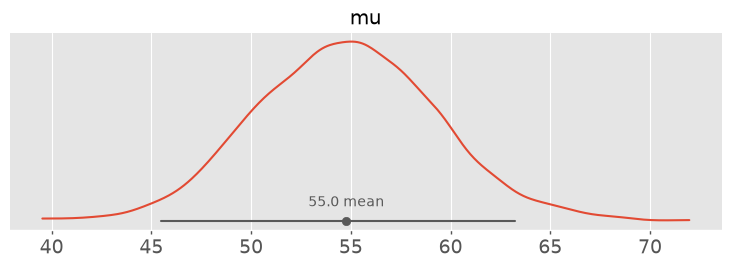

In [15]:
single_mean_prior_scale = 1
single_mean_null_value = 35

with pm.Model() as single_mean_model:

  sigma = pm.HalfFlat("sigma")
  pm.Potential("jeffrey", -pm.math.log(sigma))

  delta = pm.Cauchy("delta", alpha = 0, beta = single_mean_prior_scale)
  mu = pm.Deterministic("mu", single_mean_null_value + delta * sigma)

  y = pm.Normal("y", mu = mu, sigma = sigma, observed = single_mean_data)

  single_mean_trace = pm.sample()

azp.plot_dist(single_mean_trace, var_names=["mu"], ci_kind="hdi", ci_prob=0.95)


As you can see we got the same result.


Since we used the JZS prior, we put more emphasis on the observations. Using the observations solely, we converge to 55.5, and the interval we got is not far from that value even though we set $\mu_0 = 35$.


In [16]:
single_mean_delta_samples = single_mean_trace.posterior["delta"].values.flatten()

single_mean_posterior_density_at_null = stats.norm.pdf(
    0,
    loc = single_mean_delta_samples.mean(),
    scale = single_mean_delta_samples.std()
)
single_mean_prior_density_at_null = stats.cauchy.pdf(0, loc = 0, scale = single_mean_prior_scale)

single_mean_bf01 = single_mean_posterior_density_at_null / single_mean_prior_density_at_null
single_mean_bf10 = 1 / single_mean_bf01

print("Bayes Factor (BF10):", single_mean_bf10)


Bayes Factor (BF10): 206.7653799508147


The Bayes factor is above 100, so the data provide a very strong evidence for $H_1$. This aligns with what we already saw in the HDI, which is far from the null value of 35.


**Example 2: Paired Samples (Page 102)**

Data:

$n = 10$

$\bar{y} = 0.0804$

$s = 0.0523$

Our hypotheses are:

$H_0: \mu_{diff} = 0$

$H_1: \mu_{diff} \neq 0$

Under the assumption of

$y \sim \mathcal{N}(\mu,\sigma^2)$

The corresponding JZS priors are:

$\mu \sim C(0, r^2\sigma^2)$

or equivalently

$\delta \sim C(0,r^2)$

$\mu = \delta\sigma$

$p(\sigma^2) \propto \frac{1}{\sigma^2}$

$p(\sigma) \propto \frac{1}{\sigma} ; \sigma > 0$

As suggested we will use $r = 1$.


In [17]:
#difference of paired samples
paired_data = np.array([0.015, 0.028, 0.177, 0.121, 0.102, 0.107, 0.019, 0.066, 0.058,
       0.111])

print("Sample Size:", paired_data.shape[0])
print("Mean:", paired_data.mean())
print("Standard Deviation:", paired_data.std(ddof=1))


Sample Size: 10
Mean: 0.0804
Standard Deviation: 0.05227321387564466


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, delta]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


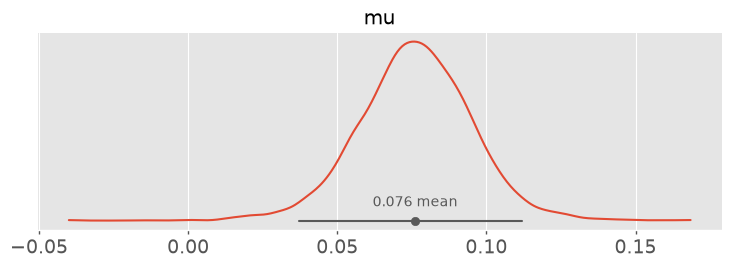

In [18]:
paired_prior_scale = 1

with pm.Model() as paired_model:
  sigma = pm.HalfFlat("sigma")
  pm.Potential("jeffrey",-pm.math.log(sigma))

  delta = pm.Cauchy("delta", alpha = 0, beta = paired_prior_scale)
  mu = pm.Deterministic("mu", delta * sigma)

  likelihood = pm.Normal("likelihood",mu = mu,sigma = sigma,observed = paired_data)

  paired_trace = pm.sample()

azp.plot_dist(paired_trace, var_names=["mu"], ci_kind="hdi", ci_prob=0.95)


Since 0 is not in the HDI, we reject $H_0$.


In [19]:
az.summary(paired_trace, ci_kind="hdi", ci_prob=0.95)


,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
delta,1.4,0.47,0.53,2.3,1200,1542,1.00,0.014,0.0098
sigma,0.0578,0.015,0.037,0.094,1120,1591,1.00,0.00043,0.00055
mu,0.0761,0.0191,0.038,0.11,2877,2454,1.00,0.00035,0.00031


In [20]:
paired_delta_samples = paired_trace.posterior["delta"].values.flatten()

paired_posterior_density_at_null = stats.norm.pdf(
    0,
    loc = paired_delta_samples.mean(),
    scale = paired_delta_samples.std()
)
paired_prior_density_at_null = stats.cauchy.pdf(0, loc = 0, scale = paired_prior_scale)

paired_bf01 = paired_posterior_density_at_null / paired_prior_density_at_null
paired_bf10 = 1 / paired_bf01

print("Bayes Factor (BF10):", paired_bf10)


Bayes Factor (BF10): 34.255130076930314


The Bayes factor lands in the strong range but nowhere near the decisive one. With only ten pairs this is about as much as we can ask for, and it shows how the Bayes factor keeps the amount of information in the sample visible in the answer instead of collapsing it into a single reject or fail to reject verdict.


**Example 3: Independent Samples (Page 104)**

Data (mother's age in years):

Group 1 (younger mothers):

$n_1 = 844$

$\bar{y}_1 = 30.56$

$s_1 = 14.35$

Group 2 (mature mothers):

$n_2 = 129$

$\bar{y}_2 = 28.79$

$s_2 = 13.48$

Remember in frequentist statistics the two sided hypothesis of independent samples is the following:

$H_0: \mu_1 - \mu_2 = 0$

$H_1: \mu_1 - \mu_2 \neq 0$

In Bayesian Statistics, we write the same idea in a different fashion:

$\alpha = \mu_1 - \mu_2$

$\mu = \frac {\mu_1 + \mu_2}{2}$

$\mu_1 = \mu + \frac \alpha 2$

$\mu_2 = \mu - \frac \alpha 2$

The corresponding hypotheses are:

$H_0: \mu_1 - \mu_2 = \alpha = 0$

$H_1: \alpha \neq 0$

Under the assumption of

$\text{young} \sim \mathcal{N}(\mu + \alpha/2, \sigma_1^2)$

$\text{mature} \sim \mathcal{N}(\mu - \alpha/2, \sigma_2^2)$

We assume the variances are equal for this particular example:

$\sigma_1^2 = \sigma_2^2 = \sigma^2$

Assigning informative priors to $\mu$ and $\sigma$ is hard. But assigning a prior on the standardized difference $\delta$ is easier. Moreover, in the hypothesis environment we configured, we are not interested in $\mu$ or $\sigma$. We are only interested in $\delta$. Hence the corresponding JZS priors are:

$p(\mu) \propto 1$

$p(\sigma^2) \propto \frac{1}{\sigma^2}$

$p(\sigma) \propto \frac{1}{\sigma} ; \sigma > 0$

$\alpha \sim C(0, r^2\sigma^2)$

or equivalently

$\delta \sim C(0,r^2)$

$\alpha = \delta\sigma$

As suggested we will use $r = 1$.



In [21]:
mature_mom = np.array([ 2., 20., 43., 30., 52., 15., 10., 30., 50., 29., 34., 22., 32.,
       35., 55., 20., 35., 20., 30., 30., 50., 30., 20., 18., 10.,  0.,
       20., 25., 13., 32., 24., 16., 15., 25., 29., 10., 31., 40., 13.,
       47., 28., 24., 20., 35., 50., 20., 20., 20., 11., 23., 40., 40.,
       43., 25.,  7., 37.,  2., 35., 17., 56., 25., 25., 40., 65., 25.,
       45., 45., 23., 30., 70., 20., 38., 29., 35., 35., 25., 18., 17.,
       10., 40., 29., 10., 36., 23., 30., 20., 40., 37., 45., 25., 44.,
       30., 65., 50., 13., 20., 37., 20., 35., 30., 34., 16., 30., 27.,
       40., 50., 25., 35., 24., 38., 29., 25., 27., 30., 15., 35., 23.,
       28., 61., 12., 10., 20., 40.,  0., 26., 20., 32., 25., 23.])

younger_mom = np.array([38., 20., 38., 34., 27., 22., 76., 15., 52., 28., 34., 12., 30.,
       75., 35.,  9., 12., 20., 39., 40., 38., 36., 20., 30., 30., 50.,
       68., 27., 22., 72., 25., 35., 10., 30., 25.,  1., 27., 30., 11.,
       50., 41., 20., 48., 35., 40., 30., 57., 28., 60., 10., 35., 18.,
       23., 26., 32., 56., 60., 28., 13., 23., 15., 47., 50., 17., 33.,
       25., 20.,  4., 10., 40., 22., 50., 16., 30.,  0., 23., 30., 35.,
       25., 46., 40., 36., 51., 55., 55., 25., 35., 35., 27., 38., 38.,
       36., 12., 48.,  0., 37., 47., 20., 20., 32.,  5., 50., 35., 24.,
       25., 30., 35., 35., 23., 30., 50., 19., 18., 46., 24., 35., 29.,
       18., 70., 35., 23., 20., 14., 35., 50., 60., 18., 40., 40., 27.,
       25., 22., 35., 28., 20., 10., 35., 25., 33., 31., 34., 52., 45.,
       52., 25., 25., 47., 19., 45., 45., 55., 41., 27., 55., 21., 24.,
       23., 39., 70., 26., 35., 30., 23., 20.,  6., 18., 32., 13., 40.,
       47., 40.,  2., 62., 18., 58., 25., 40., 26., 22., 28., 36., 17.,
       38., 32., 15., 40., 60., 13., 30., 35., 32., 27., 37., 30., 55.,
       26., 40., 30., 23., 12., 29.,  0., 30.,  0., 40., 41., 20., 56.,
       16., 25., 25., 65., 10., 13., 16., 31., 40., 15., 50., 21., 34.,
       24., 20., 32., 23., 11., 45., 32., 20., 45., 35.,  1., 31., 17.,
       15., 26., 32., 28., 10., 56., 23.,  9., 45., 35., 39., 31., 50.,
       80., 25., 29., 45., 85., 20., 30., 10., 37., 30., 23., 36., 41.,
       20., 19., 34., 30., 27., 18., 54., 50., 27., 38.,  0., 35., 30.,
       20., 35., 25., 10., 28., 11., 22., 23., 40., 30., 30., 29., 39.,
       30., 19., 36., 31., 25., 30., 12., 13.,  9., 20., 47.,  8.,  0.,
       35., 28., 24., 30., 35., 30., 33., 33., 30., 22., 54., 55., 56.,
       25., 40., 40., 60., 62., 50., 28., 30., 15., 30., 20., 30., 27.,
       23., 30., 35., 35., 40., 20., 10., 40., 15., 36.,  8., 58., 45.,
       30., 41., 10., 20., 50., 20., 35., 18., 15., 30., 28., 60., 13.,
       35., 35., 37., 46., 58.,  0., 26., 21., 20., 29., 28., 70., 29.,
       50., 30., 40., 23., 34., 47., 22., 12., 31., 13., 18., 30., 31.,
       27.,  0., 35., 38., 20., 20., 50., 50., 38., 20., 53., 36., 20.,
       25., 28., 34., 48., 27., 60., 47., 18., 31., 30., 26., 40., 33.,
       31., 50., 32., 29., 33., 35., 13., 41., 20., 32., 13., 24., 26.,
       25., 44., 37., 33., 30., 35., 23., 18., 30.,  0., 20., 40., 40.,
       32., 45., 21., 27., 43., 30., 25., 27., 35., 55., 40., 35., 27.,
       38., 38., 29., 38., 38., 30., 25.,  0., 68., 24., 35., 20., 19.,
       39., 40., 20., 20., 40., 15., 23., 37., 22., 55., 36., 40., 43.,
       25., 38., 31., 30., 65., 40., 10., 21., 13., 48., 19.,  0., 28.,
       58., 20., 36., 61., 50., 31., 38., 14., 15., 37., 15.,  3., 17.,
       35., 40., 43., 21., 29., 18., 40., 48., 25., 20., 50., 37., 10.,
       30., 24., 22., 31., 34., 12., 40., 24., 58., 42., 23.,  5., 22.,
       38., 30., 30., 20., 19., 14., 18.,  0., 32., 40., 31., 21., 35.,
       47., 45., 28.,  0.,  0., 72., 35., 39.,  0., 13., 35., 14., 43.,
       33., 20., 20., 19., 24., 18., 35., 35., 16., 35., 20., 34., 33.,
       25., 32., 20., 30., 70., 41., 34., 25., 35., 18., 14., 40., 25.,
       40., 25., 40., 35., 30., 20., 30., 20., 38., 26.,  0., 30., 30.,
       20., 30., 29., 50., 25., 45., 17., 36., 39., 30., 25., 30., 35.,
       28., 25., 55., 40., 15., 34., 23., 20., 30., 51., 30., 14., 55.,
       12., 25., 24., 20., 35., 40., 20., 30., 33., 45., 13., 50., 25.,
       15., 20., 30., 25., 40., 25., 19., 57., 29., 40., 22., 27., 25.,
       47., 28., 59., 47., 40., 45., 23., 35., 21., 35., 38., 43., 30.,
        0., 30., 30., 50., 42., 20.,  1., 44., 17., 19., 30., 30., 21.,
       14., 20.,  0., 22., 45., 26., 44., 54., 38., 44., 40., 33., 34.,
       46.,  3., 41., 35., 28., 44., 34., 12., 20., 19., 40., 50., 37.,
       35., 50., 30., 34., 14., 33., 25., 32., 45., 42., 30., 35., 29.,
       30., 22., 85., 37., 30., 56., 20., 55.,  7., 20., 20., 31., 34.,
       55., 42., 25., 28., 30., 55., 21., 20., 43., 25., 32., 22., 26.,
       30., 27., 28., 22., 10., 29., 42., 20., 45., 24., 22., 25., 48.,
       25., 16., 37., 35., 27., 30., 35., 30., 22., 29., 36., 35., 60.,
       10., 23., 15., 60.,  3., 35., 26., 20., 15., 28., 25.,  0., 41.,
       44.,  0., 20., 17., 40., 24.,  6., 18., 21., 24., 30.,  0., 41.,
       30.,  0., 35., 23., 36., 40.,  0., 30., 18., 35., 25., 77., 45.,
       60., 30.,  0., 25., 20., 23., 15., 33., 35., 30., 35., 75., 20.,
       32., 60., 42., 30., 23., 40., 36., 34.,  0., 30., 40., 15., 25.,
       25., 36., 20., 25., 28., 23., 20., 57.,  0., 40., 35., 28., 22.,
       15., 38., 33., 40., 44., 60., 34., 29., 22., 15., 14., 21.])

In [22]:
for group_name, group_data in [("young", younger_mom), ("mature", mature_mom)]:
    print("Group:", group_name)
    print("Sample Size:", group_data.shape[0])
    print("Mean:", group_data.mean())
    print("Standard Deviation:", group_data.std(ddof=1))
    print()


Group: young
Sample Size: 844
Mean: 30.56042654028436
Standard Deviation: 14.346910101964047

Group: mature
Sample Size: 129
Mean: 28.790697674418606
Standard Deviation: 13.482439051992696



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, delta]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


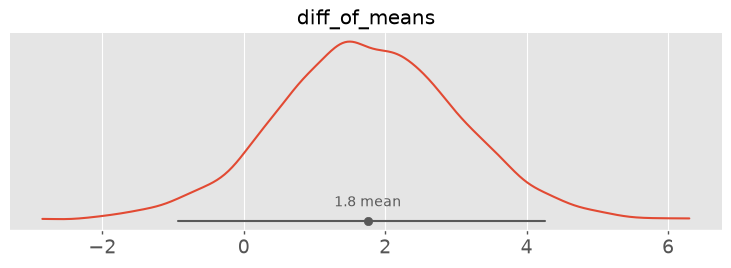

In [23]:
independent_samples_prior_scale = 1

with pm.Model() as independent_samples_model:

  mu = pm.Flat('mu')

  sigma = pm.HalfFlat("sigma")
  pm.Potential("jeffrey", -pm.math.log(sigma))

  delta = pm.Cauchy("delta", alpha = 0, beta = independent_samples_prior_scale)
  alpha = delta * sigma

  mu_young = mu + alpha/2
  mu_mature = mu - alpha/2

  likelihood_young = pm.Normal("young", mu_young, sigma, observed = younger_mom)
  likelihood_mature = pm.Normal("mature", mu_mature, sigma, observed = mature_mom)

  diff_of_means = pm.Deterministic("diff_of_means", mu_young-mu_mature)

  independent_samples_trace = pm.sample()

azp.plot_dist(independent_samples_trace, var_names=["diff_of_means"], ci_kind="hdi", ci_prob=0.95)


Since 0 is inside the 95% HDI, we cannot say that the two groups are different from each other.


In [24]:
independent_samples_delta_samples = independent_samples_trace.posterior["delta"].values.flatten()

independent_samples_posterior_density_at_null = stats.norm.pdf(
    0,
    loc = independent_samples_delta_samples.mean(),
    scale = independent_samples_delta_samples.std()
)
independent_samples_prior_density_at_null = stats.cauchy.pdf(0, loc = 0, scale = independent_samples_prior_scale)

independent_samples_bf01 = independent_samples_posterior_density_at_null / independent_samples_prior_density_at_null
independent_samples_bf10 = 1 / independent_samples_bf01

print("Bayes Factor (BF10):", independent_samples_bf10)


Bayes Factor (BF10): 0.17991782413663113


This time the Bayes factor is below 1, so we read it in reverse. We get a $BF_{01}$ of roughly 6, meaning the data are several times more likely under $H_0$ than under $H_1$. On Jeffreys' scale this counts as substantial evidence for $H_0$.


**Example 4: Independent Samples with a Smaller Prior Scale (Page 107)**

Data (birth weight in pounds):

Group 1 (babies of nonsmoker mothers):

$n_1 = 873$

$\bar{y}_1 = 7.14$

$s_1 = 1.52$

Group 2 (babies of smoker mothers):

$n_2 = 126$

$\bar{y}_2 = 6.83$

$s_2 = 1.39$

Our hypotheses are:

$H_0: \alpha = 0$

$H_1: \alpha \neq 0$

Under the assumption of

$\text{nonsmokers} \sim \mathcal{N}(\mu+\alpha/2,\sigma^2)$

$\text{smokers} \sim \mathcal{N}(\mu-\alpha/2,\sigma^2)$

The corresponding JZS priors are:

$p(\mu) \propto 1$

$p(\sigma^2) \propto \frac{1}{\sigma^2}$

$p(\sigma) \propto \frac{1}{\sigma} ; \sigma > 0$

$\alpha \sim C(0, r^2\sigma^2)$

or equivalently

$\delta \sim C(0,r^2)$

$\alpha = \delta\sigma$

This time we will use $r = 0.5$ instead of $r = 1$.



In [25]:
smokers = np.array([7.56, 6.88, 5.81, 7.44, 7.06, 8.06, 7.44, 7.88, 6.19, 1.69, 6.75,
       6.94, 8.38, 7.31, 7.94, 8.38, 6.19, 8.25, 6.69, 5.25, 6.31, 7.5 ,
       7.44, 9.06, 7.38, 5.38, 4.13, 2.69, 7.69, 7.44, 6.38, 9.13, 8.31,
       5.06, 8.63, 5.5 , 6.25, 7.81, 6.63, 6.88, 6.94, 6.  , 7.81, 6.38,
       8.38, 6.31, 7.13, 6.5 , 8.13, 7.31, 5.75, 7.31, 7.5 , 7.06, 5.75,
       6.13, 7.19, 8.13, 6.88, 7.38, 7.13, 7.5 , 5.  , 5.81, 6.  , 7.31,
       9.06, 5.94, 6.5 , 7.13, 4.5 , 8.  , 7.31, 9.13, 7.13, 7.31, 7.38,
       7.75, 7.25, 6.25, 8.88, 8.56, 6.75, 7.56, 7.81, 8.38, 7.  , 4.75,
       8.25, 7.44, 7.  , 7.94, 4.06, 3.31, 7.69, 5.69, 8.69, 4.88, 5.94,
       7.81, 6.5 , 6.88, 6.38, 6.  , 6.5 , 9.19, 6.  , 7.06, 8.13, 4.75,
       5.94, 4.44, 8.19, 9.13, 6.31, 6.44, 5.63, 7.06, 5.38, 6.88, 7.5 ,
       8.19, 2.19, 6.06, 6.75, 5.5])

nonsmokers = np.array([7.63,  7.88,  6.63,  8.  ,  6.38,  5.38,  8.44,  4.69,  8.81,
        6.94,  7.44,  8.81,  6.  ,  7.13,  1.5 ,  8.25,  6.19,  7.  ,
        7.19,  6.  ,  7.63,  9.5 ,  5.56,  7.5 ,  7.44,  7.56,  6.06,
        7.  ,  4.56,  2.63,  6.38,  7.25,  1.56,  7.44,  6.  ,  6.5 ,
        7.31,  7.88,  6.19,  7.  ,  5.81,  7.44,  7.75,  8.  ,  6.63,
        8.31,  7.25,  5.5 ,  7.81,  7.  ,  7.31,  9.06,  6.56,  5.88,
        6.63,  9.06,  8.75,  7.06,  6.88,  5.94,  8.56,  6.19,  4.44,
        4.75,  5.5 ,  7.88,  7.5 ,  7.88,  5.94,  8.56,  9.25,  7.69,
        5.94,  9.5 ,  6.06,  6.94,  8.19,  6.75,  6.25,  8.  ,  8.31,
        7.75,  4.69,  5.38,  8.38,  6.88,  2.88,  5.88,  1.38,  6.5 ,
        6.31,  5.25,  7.25,  9.94,  7.31,  5.63,  6.5 ,  5.63,  6.31,
        9.56,  5.44,  6.75,  8.38,  7.19,  7.19,  6.06,  7.19,  5.94,
        8.56,  6.69,  7.5 ,  7.44,  7.88,  8.75,  7.44,  7.44,  6.38,
        8.81,  7.  ,  7.19,  5.94,  6.75,  8.13,  6.38,  7.13,  6.88,
        8.44,  8.31,  7.25,  6.06,  5.75,  6.75,  8.06,  9.  ,  6.25,
        7.06,  8.  ,  8.31,  7.75,  7.44,  8.44,  6.94,  4.5 ,  6.38,
        7.63,  4.5 ,  4.94,  6.13,  7.75,  8.38,  6.81,  6.  ,  9.56,
        7.56,  7.44,  7.38,  5.94,  7.  ,  6.94,  6.94,  6.38,  7.19,
        7.63,  8.38,  7.5 ,  7.88,  7.63,  7.75,  5.44,  6.5 ,  8.06,
        6.75,  8.19,  5.88,  8.06,  6.88,  9.06,  7.13,  8.13,  6.75,
        7.88,  7.69,  5.44,  5.81,  4.25,  9.88,  6.81,  2.5 ,  5.94,
        7.56,  4.63,  7.25,  6.5 ,  8.19,  6.75,  8.  ,  8.38,  8.25,
        6.88,  7.5 ,  7.5 ,  8.44,  7.94,  9.  ,  7.5 ,  7.69,  7.19,
        7.25,  7.44,  7.69,  7.81,  6.69,  5.44,  7.  ,  7.69, 10.19,
        7.25,  9.  ,  5.88,  7.06,  7.5 ,  8.56,  7.38,  7.19,  6.  ,
        5.81,  8.  ,  6.38,  7.19,  8.38,  8.44,  7.31,  7.31,  5.  ,
        4.69,  3.75,  5.88,  2.69,  1.  ,  7.19,  8.88,  8.81,  6.75,
        6.81,  6.44,  9.88,  6.88,  8.75,  6.69,  7.88,  5.88,  9.  ,
        7.75,  6.06,  7.  ,  5.38,  7.31,  8.44,  7.63,  8.44,  6.88,
        8.38,  8.38,  7.63,  7.81,  8.19,  7.31,  7.5 ,  7.25,  7.13,
        7.81,  8.69,  1.19,  5.88,  9.25,  6.25,  1.44,  8.56,  5.13,
        5.44,  6.69,  5.5 ,  6.44,  5.88,  7.25,  8.19,  5.94,  7.13,
        6.69, 10.06,  7.81,  6.31,  8.19,  7.31,  7.63,  7.69,  9.  ,
        5.88,  7.13,  8.75,  6.5 ,  8.38,  3.75,  7.44,  9.13,  7.31,
        6.31,  6.25,  8.5 ,  8.31,  6.56,  7.13,  5.94,  7.5 ,  7.19,
        6.88,  6.63,  7.06,  7.19,  6.94,  7.81,  8.5 ,  7.25,  8.5 ,
        5.81,  7.5 ,  8.13,  5.06,  7.38,  6.25,  8.75,  6.94,  8.13,
        8.25,  8.  ,  6.31,  7.75,  7.75,  7.06,  7.88,  7.69,  7.94,
        6.88,  6.75,  7.94,  8.75,  8.56,  7.38,  3.94,  8.75,  8.19,
        9.19,  6.06,  7.44,  7.38,  8.06,  7.56,  6.88,  7.75,  7.63,
        9.38,  8.31,  7.63,  6.88,  5.63,  8.38,  9.  ,  8.75,  7.94,
        7.  ,  6.75,  5.19,  1.69,  6.13,  6.88,  7.19,  5.94,  9.  ,
        7.25,  7.19,  6.94,  7.13,  7.56,  8.25,  8.38,  6.75,  5.38,
        7.13,  8.75,  7.75,  8.44,  8.  ,  8.19,  7.94,  7.38,  9.31,
        8.88,  8.06,  7.06,  6.56,  8.19,  8.31,  5.88,  7.44,  7.44,
        6.75,  7.44,  7.5 ,  6.56,  7.  ,  7.69,  8.  ,  2.25,  8.19,
        3.44,  6.5 ,  4.  ,  7.5 ,  8.  ,  8.  ,  6.63,  6.75,  7.44,
        6.25,  6.56,  5.63,  4.56,  8.5 ,  8.88,  6.25,  7.06,  7.94,
        6.31,  9.06,  9.13,  7.06,  8.25,  7.75,  8.25,  5.75,  7.69,
        6.69,  7.75,  6.81,  8.  ,  6.56,  9.63,  8.25,  7.56,  7.19,
        7.69,  1.38,  4.06,  7.38,  5.56,  7.44,  6.75,  8.38,  7.81,
        8.13,  8.06,  7.38,  9.25,  7.63,  8.38,  7.5 ,  8.  ,  8.13,
        7.31,  7.56,  7.44,  7.06,  7.5 ,  7.25,  8.56,  7.94,  8.13,
        7.06,  6.44,  5.81,  8.44,  6.44,  7.56,  8.25,  6.38,  7.13,
        5.56,  6.88,  7.75,  7.25,  7.75,  8.13,  8.19,  8.5 ,  5.69,
        6.38,  1.88,  3.56,  6.25,  3.19,  7.31,  6.13,  7.38,  7.88,
        8.94,  8.06,  7.69,  8.56,  7.13,  9.81,  6.81,  8.31,  8.44,
        6.94,  8.5 ,  7.88,  7.94,  7.  ,  7.81,  5.38,  6.25,  6.19,
        7.88,  6.5 ,  7.  ,  7.13,  7.69,  9.56,  6.5 ,  7.44,  6.31,
        8.5 ,  7.31,  5.  ,  5.44,  6.81,  6.31,  9.75,  8.25,  6.63,
        7.56,  7.81,  6.81,  5.44,  7.94,  7.38,  1.  ,  6.  ,  6.  ,
        8.25,  6.06,  6.56,  8.19,  8.63,  6.75,  8.13,  5.81,  9.75,
        7.63,  4.56,  8.75,  7.13,  7.31,  5.63,  8.44,  7.88,  7.25,
       11.75,  6.88,  7.5 ,  6.88,  7.63,  8.38,  7.56,  7.25,  4.19,
        7.06,  6.06,  2.94,  6.  ,  5.5 ,  8.69,  8.  ,  6.81,  6.56,
        9.19,  9.19,  7.44,  7.38,  7.81,  7.81,  7.88,  8.  ,  6.56,
        6.13,  7.44,  7.63,  7.5 ,  6.31,  5.25,  4.75,  7.25,  8.13,
        9.25,  8.06,  6.63,  7.13,  6.38,  9.5 ,  7.13,  8.81,  7.88,
        6.25,  8.  ,  7.88, 10.38,  8.81,  6.5 ,  7.  ,  8.19,  7.63,
        7.19,  7.06,  1.31,  2.88,  6.  ,  5.94,  5.25,  7.19,  4.75,
        6.13,  9.38,  7.13,  7.38,  7.44,  5.81,  9.13,  6.25,  8.5 ,
       11.63,  6.75,  5.56,  6.  ,  6.69,  9.5 ,  8.88,  9.19,  9.31,
        7.38,  8.88,  6.19,  8.81,  7.31,  7.38,  5.  ,  9.25,  6.69,
        6.81,  3.  ,  4.63,  5.56,  4.44,  1.44,  1.5 ,  5.06,  6.81,
        8.81,  6.56,  6.75,  7.94,  7.31,  6.44,  3.94,  8.06,  9.25,
        7.38,  7.38,  7.56,  8.81,  6.  ,  6.88,  8.06,  6.69,  7.06,
        6.88,  9.63,  7.88,  8.88,  7.81,  7.38,  7.5 ,  7.31,  8.25,
        6.56,  8.81,  7.88,  8.31,  5.88,  8.63,  9.31,  7.88,  9.63,
       10.06,  7.13,  6.81,  5.63,  6.56,  7.13,  8.19,  8.  ,  8.63,
        6.69,  6.38,  8.5 ,  6.81,  7.88,  7.56,  7.25,  6.88,  8.5 ,
        8.5 ,  4.75,  8.75,  6.44,  7.  ,  7.25,  8.25,  8.5 ,  7.44,
        7.75,  8.5 ,  8.13,  6.94,  7.25,  9.69,  6.31,  6.75,  6.88,
        8.75,  9.31,  7.88,  7.63,  8.31,  7.88,  7.56,  6.19,  7.94,
        7.19,  6.31,  4.69,  3.81,  2.88, 10.13,  7.06,  8.56,  6.94,
        8.81,  8.44,  8.13,  7.63,  8.44,  8.88,  8.25,  7.88,  7.31,
        7.88,  7.5 ,  5.19,  8.06,  8.94,  7.69,  6.63,  7.63,  7.56,
        6.38,  6.25,  7.13,  7.94,  6.5 ,  6.44,  8.69,  5.63,  2.25,
        6.75,  1.63,  8.88,  7.06,  8.81,  7.56,  9.19,  6.19,  5.38,
        7.19,  6.75,  7.38,  6.06,  6.88,  7.  ,  8.56,  8.19,  7.  ,
        8.13,  9.13,  7.81,  7.  ,  8.25,  8.  , 10.25,  7.69,  7.06,
        3.25,  4.  ,  4.13,  5.13,  9.88,  6.19,  7.81,  8.75,  9.31,
        7.  ,  6.69,  8.63,  8.5 ,  8.94,  6.31,  7.25,  7.  ,  7.94,
        6.25,  7.94,  8.31,  8.5 ,  8.38,  4.94,  5.94,  4.31,  3.63,
        8.75,  7.  ,  6.25,  8.94,  8.38,  7.56,  7.75,  7.25, 10.13,
        1.38,  5.5 ,  8.06,  7.81,  7.5 ,  7.19,  7.31,  9.88,  9.19,
        8.13,  9.  ,  7.44,  5.69,  7.81,  6.69,  6.38,  7.44,  5.88,
        7.69,  7.56,  6.56,  5.69,  8.44,  6.19,  6.94,  4.56,  7.13])

In [26]:
for group_name, group_data in [("nonsmokers", nonsmokers), ("smokers", smokers)]:
    print("Group:", group_name)
    print("Sample Size:", group_data.shape[0])
    print("Mean:", group_data.mean())
    print("Standard Deviation:", group_data.std(ddof=1))
    print()


Group: nonsmokers
Sample Size: 873
Mean: 7.144272623138602
Standard Deviation: 1.518680606114912

Group: smokers
Sample Size: 126
Mean: 6.828730158730159
Standard Deviation: 1.386179777158495



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, mu, delta]


c:\Users\egemen.u.dalgic\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


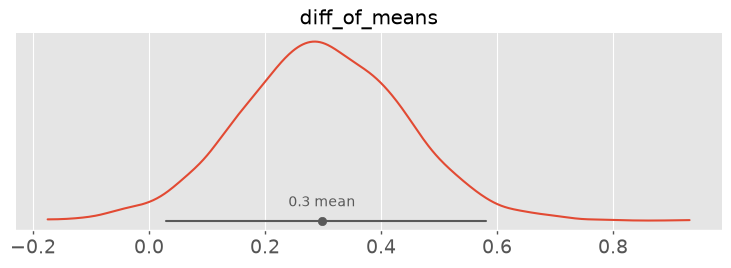

In [27]:
smoking_prior_scale = 0.5

with pm.Model() as smoking_model:

  sigma = pm.HalfFlat("sigma")
  pm.Potential("jeffrey", -pm.math.log(sigma))

  mu = pm.Flat('mu')
  delta = pm.Cauchy("delta", alpha = 0, beta = smoking_prior_scale)
  alpha = delta * sigma

  mu_smokers = mu - alpha/2
  mu_nonsmokers = mu + alpha/2

  likelihood_smokers = pm.Normal("smokers", mu_smokers, sigma, observed = smokers)
  likelihood_nonsmokers = pm.Normal("nonsmokers", mu_nonsmokers, sigma, observed = nonsmokers)

  diff_of_means = pm.Deterministic("diff_of_means", mu_nonsmokers-mu_smokers)

  smoking_trace = pm.sample()

azp.plot_dist(smoking_trace, var_names=["diff_of_means"], ci_kind="hdi", ci_prob=0.95)


Since 0 is not in the HDI, we reject $H_0$. The babies of nonsmoker mothers are heavier on average, and the posterior puts the difference around 0.3 pounds.



In [28]:
smoking_delta_samples = smoking_trace.posterior["delta"].values.flatten()

smoking_posterior_density_at_null = stats.norm.pdf(
    0,
    loc = smoking_delta_samples.mean(),
    scale = smoking_delta_samples.std()
)
smoking_prior_density_at_null = stats.cauchy.pdf(0, loc = 0, scale = smoking_prior_scale)

smoking_bf01 = smoking_posterior_density_at_null / smoking_prior_density_at_null
smoking_bf10 = 1 / smoking_bf01

print("Bayes Factor (BF10):", smoking_bf10)


Bayes Factor (BF10): 1.3975929791140393


Here the Bayes factor is barely above 1, which on Jeffreys' scale is not worth more than a bare mention. Yet the HDI for the difference excluded 0 and led us to reject $H_0$. So overall we do not have enough evidence to claim a difference between the groups, but if there is any, it is around 0.3 pounds.
